In [1]:
import torch
import torch.nn as nn
from torchvision import transforms, datasets
from torchvision.models import resnet50, ResNet50_Weights
from torch.utils.data import DataLoader

device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print(device)

mps


In [3]:
import os

print(os.getcwd())
print(os.listdir())

/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon
['IDRiD Dataset', '.DS_Store', 'FourSep.ipynb', 'Testing.ipynb', 'retinopathy_model.ipynb', 'retinopathy_best.pth', '.ipynb_checkpoints', 'archive.zip', 'retinopathy_cnn.pth', 'aptos2019-blindness-detection.zip', 'aptos2019-blindness-detection', 'SIH Frontend']


In [4]:
train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

In [9]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import pandas as pd
import os
from sklearn.model_selection import train_test_split

train_dir = "IDRiD/Train/images"
csv_path = "IDRiD/Train/annotations.csv"

df = pd.read_csv(csv_path)

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Retinopathy grade"],
    random_state=42
)

print(len(train_df), len(val_df))

FileNotFoundError: [Errno 2] No such file or directory: 'IDRiD/Train/annotations.csv'

In [6]:
train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

In [8]:
import os

print(os.path.exists("IDRiD Dataset"))
print(os.listdir("IDRiD Dataset"))

True
['.DS_Store', 'Test', 'Train']


In [10]:
import os

for root, dirs, files in os.walk("IDRiD Dataset"):
    print(root)
    for f in files:
        if "annotation" in f.lower():
            print("   CSV:", f)

IDRiD Dataset
IDRiD Dataset/Test
   CSV: annotations.csv
IDRiD Dataset/Test/images
IDRiD Dataset/Train
   CSV: annotations.csv
IDRiD Dataset/Train/images
IDRiD Dataset/Train/.ipynb_checkpoints


In [11]:
import pandas as pd
import os

train_dir = "IDRiD Dataset/Train/images"
csv_path = "IDRiD Dataset/Train/annotations.csv"

print(os.path.exists(train_dir))
print(os.path.exists(csv_path))

df = pd.read_csv(csv_path)

print(df.shape)
print(df.head())

True
True
(1239, 5)
       Image name  Retinopathy grade  Risk of macular edema  \
0  IDRiD_0001.jpg                  0                      0   
1  IDRiD_0002.jpg                  1                      0   
2  IDRiD_0003.jpg                  2                      2   
3  IDRiD_0004.jpg                  0                      0   
4  IDRiD_0005.jpg                  3                      2   

                                  class  \
0                                 No_DR   
1                    Mild_Moderate_NPDR   
2  Clinically_Significant_Macular_Edema   
3                                 No_DR   
4  Clinically_Significant_Macular_Edema   

                                             caption  
0  A fundus photograph of a healthy retina, class...  
1  A fundus image of a patient with Mild_Moderate...  
2  This fundus photograph illustrates Clinically_...  
3  A fundus photograph of a healthy retina, class...  
4  This fundus photograph illustrates Clinically_...  


In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Retinopathy grade"],
    random_state=42
)

print(len(train_df), len(val_df))

991 248


In [13]:
from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torchvision import transforms
import os

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


class IDRiDDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        image = Image.open(
            os.path.join(self.image_dir, row["Image name"])
        ).convert("RGB")

        label = int(row["Retinopathy grade"])

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = IDRiDDataset(
    train_df, train_dir, train_transform
)

val_dataset = IDRiDDataset(
    val_df, train_dir, val_transform
)

train_loader = DataLoader(
    train_dataset, batch_size=16, shuffle=True
)

val_loader = DataLoader(
    val_dataset, batch_size=16, shuffle=False
)

print(len(train_dataset), len(val_dataset))

991 248


In [14]:
import torch.nn as nn
from torchvision.models import resnet50, ResNet50_Weights

weights = ResNet50_Weights.DEFAULT

model = resnet50(weights=weights)

model.fc = nn.Linear(model.fc.in_features, 5)

model = model.to(device)

print("ResNet50 loaded")

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /Users/aryanshinde/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [00:08<00:00, 12.3MB/s]

ResNet50 loaded


In [15]:
import torch

class_counts = torch.bincount(
    torch.tensor(train_df["Retinopathy grade"].values)
)

weights = 1.0 / class_counts.float()
weights = weights / weights.sum() * 5

criterion = nn.CrossEntropyLoss(
    weight=weights.to(device)
)

print(weights)

tensor([0.3789, 2.5339, 0.3731, 0.6833, 1.0308])


In [16]:
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

In [17]:
num_epochs = 30
best_val_acc = 0.0

for epoch in range(num_epochs):

    # ---------- TRAIN ----------
    model.train()

    train_loss = 0.0
    train_correct = 0
    train_total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        train_loss += loss.item() * labels.size(0)

        _, predicted = torch.max(outputs, 1)
        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_loss /= train_total
    train_acc = 100 * train_correct / train_total

    # ---------- VALIDATION ----------
    model.eval()

    val_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * labels.size(0)

            _, predicted = torch.max(outputs, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss /= val_total
    val_acc = 100 * val_correct / val_total

    scheduler.step(val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.2f}%"
    )

    # ---------- SAVE BEST ----------
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "resnet50_best.pth")
        print("→ Best model saved")

print(f"\nBest Validation Accuracy: {best_val_acc:.2f}%")

Epoch 1/30 | Train Loss: 1.3924 | Train Acc: 44.40% | Val Loss: 1.0878 | Val Acc: 60.48%
→ Best model saved
Epoch 2/30 | Train Loss: 0.9379 | Train Acc: 62.76% | Val Loss: 0.8047 | Val Acc: 60.08%
Epoch 3/30 | Train Loss: 0.7394 | Train Acc: 69.22% | Val Loss: 0.7436 | Val Acc: 77.42%
→ Best model saved
Epoch 4/30 | Train Loss: 0.5331 | Train Acc: 78.20% | Val Loss: 0.6151 | Val Acc: 72.18%
Epoch 5/30 | Train Loss: 0.4264 | Train Acc: 84.36% | Val Loss: 0.4510 | Val Acc: 81.05%
→ Best model saved
Epoch 6/30 | Train Loss: 0.3254 | Train Acc: 88.60% | Val Loss: 0.4184 | Val Acc: 83.47%
→ Best model saved
Epoch 7/30 | Train Loss: 0.2431 | Train Acc: 89.51% | Val Loss: 0.4642 | Val Acc: 83.06%
Epoch 8/30 | Train Loss: 0.2090 | Train Acc: 90.92% | Val Loss: 0.4108 | Val Acc: 81.85%
Epoch 9/30 | Train Loss: 0.2563 | Train Acc: 89.71% | Val Loss: 0.3228 | Val Acc: 83.87%
→ Best model saved
Epoch 10/30 | Train Loss: 0.1931 | Train Acc: 93.74% | Val Loss: 0.2723 | Val Acc: 87.90%
→ Best model s

In [18]:
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.load_state_dict(
    torch.load("resnet50_best.pth", map_location=device)
)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in val_loader:
        images = images.to(device)

        outputs = model(images)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels,
    all_preds,
    target_names=["Grade 0", "Grade 1", "Grade 2", "Grade 3", "Grade 4"]
))

print(confusion_matrix(all_labels, all_preds))

              precision    recall  f1-score   support

     Grade 0       1.00      1.00      1.00        81
     Grade 1       0.92      0.92      0.92        12
     Grade 2       0.99      0.96      0.98        82
     Grade 3       0.93      0.95      0.94        44
     Grade 4       0.93      0.97      0.95        29

    accuracy                           0.97       248
   macro avg       0.95      0.96      0.96       248
weighted avg       0.97      0.97      0.97       248

[[81  0  0  0  0]
 [ 0 11  1  0  0]
 [ 0  1 79  2  0]
 [ 0  0  0 42  2]
 [ 0  0  0  1 28]]


In [19]:
from sklearn.metrics import confusion_matrix

y_true = np.array(all_labels)
y_pred = np.array(all_preds)

# Grade 2+ = referable
true_ref = y_true >= 2
pred_ref = y_pred >= 2

tn, fp, fn, tp = confusion_matrix(
    true_ref, pred_ref
).ravel()

sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"Sensitivity: {sensitivity*100:.2f}%")
print(f"Specificity: {specificity*100:.2f}%")

Sensitivity: 99.35%
Specificity: 98.92%


In [20]:
!pip install grad-cam

zsh:1: command not found: pip


In [21]:
!python3 -m pip install grad-cam


[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip


In [22]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

In [23]:
target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

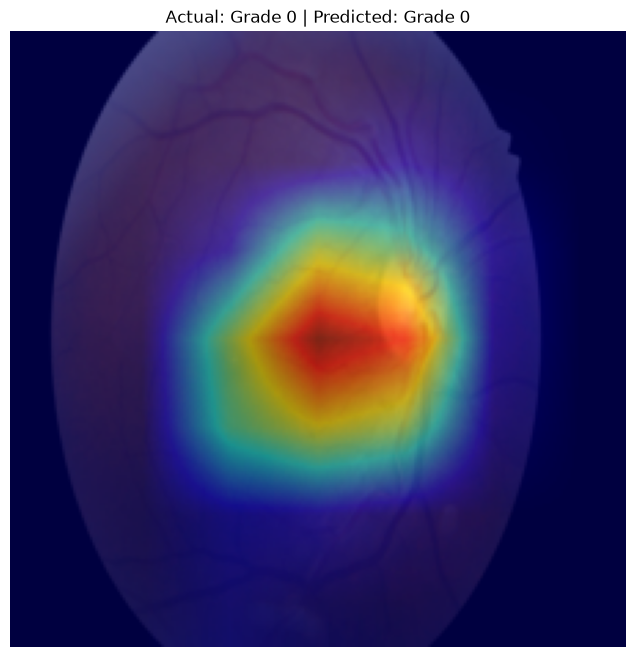

In [24]:
import numpy as np
import matplotlib.pyplot as plt

image, label = val_dataset[0]

input_tensor = image.unsqueeze(0).to(device)

output = model(input_tensor)
predicted_class = output.argmax(dim=1).item()

# Grad-CAM
grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=[ClassifierOutputTarget(predicted_class)]
)[0]

# Convert image back for visualization
img = image.permute(1, 2, 0).cpu().numpy()

mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

img = std * img + mean
img = np.clip(img, 0, 1)

visualization = show_cam_on_image(
    img,
    grayscale_cam,
    use_rgb=True
)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title(f"Actual: Grade {label} | Predicted: Grade {predicted_class}")
plt.axis("off")
plt.show()

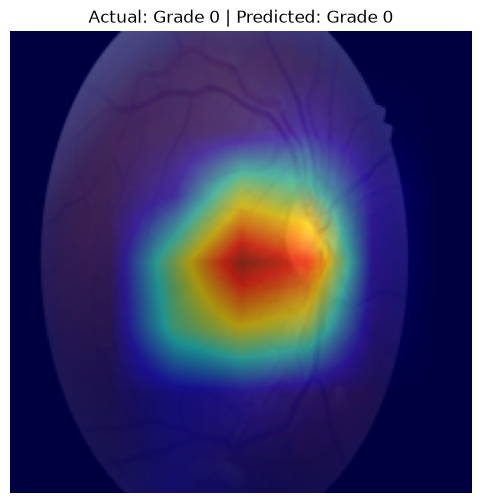

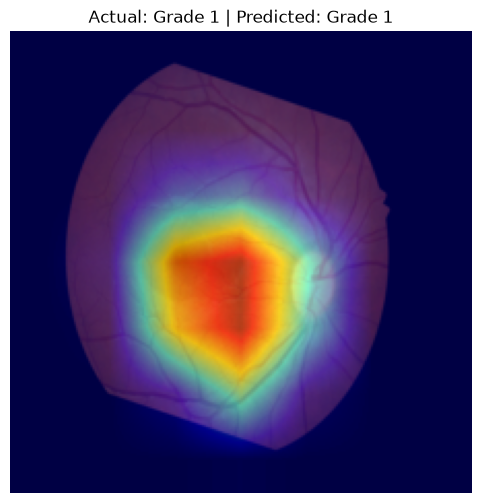

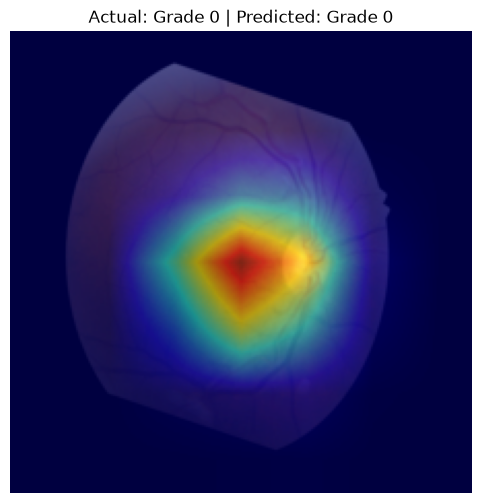

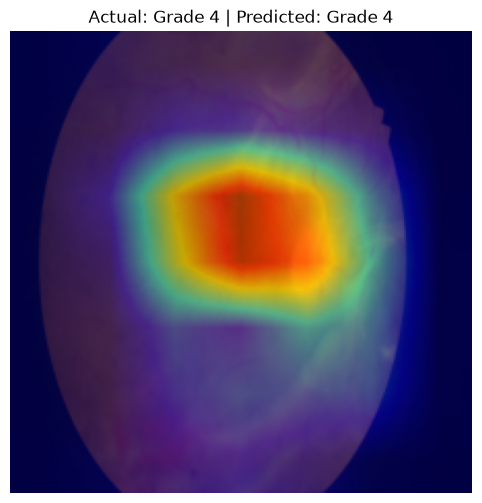

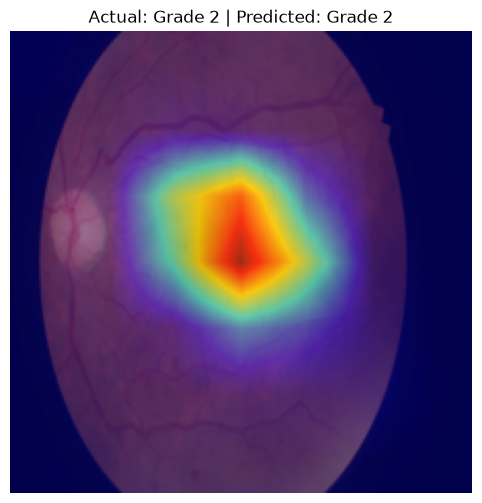

In [25]:
for idx in [0, 20, 50, 100, 150]:
    image, label = val_dataset[idx]

    input_tensor = image.unsqueeze(0).to(device)

    output = model(input_tensor)
    predicted_class = output.argmax(dim=1).item()

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=[ClassifierOutputTarget(predicted_class)]
    )[0]

    img = image.permute(1, 2, 0).cpu().numpy()
    img = np.array([0.229, 0.224, 0.225]) * img + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    visualization = show_cam_on_image(
        img,
        grayscale_cam,
        use_rgb=True
    )

    plt.figure(figsize=(6, 6))
    plt.imshow(visualization)
    plt.title(f"Actual: Grade {label} | Predicted: Grade {predicted_class}")
    plt.axis("off")
    plt.show()

In [26]:
from PIL import Image

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image_tensor = val_transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(image_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

    return predicted_class, confidence

In [27]:
image_path = "IDRiD Dataset/Train/images/IDRiD_0001.jpg"

grade, confidence = predict_image(image_path)

print("Grade:", grade)
print("Confidence:", f"{confidence*100:.2f}%")

Grade: 0
Confidence: 99.86%


In [4]:
import os
import shutil
from torchvision.datasets import CIFAR10

# Paths
fundus_dir = "/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon/IDRiD Dataset/Train/images"
gate_dataset_dir = "FundusGate"

fundus_out = os.path.join(gate_dataset_dir, "fundus")
nonfundus_out = os.path.join(gate_dataset_dir, "non_fundus")

os.makedirs(fundus_out, exist_ok=True)
os.makedirs(nonfundus_out, exist_ok=True)

# Copy IDRiD fundus images
for filename in os.listdir(fundus_dir):
    if filename.lower().endswith((".jpg", ".jpeg", ".png")):
        src = os.path.join(fundus_dir, filename)
        dst = os.path.join(fundus_out, filename)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

print("Fundus images copied.")

# Download CIFAR-10
cifar_dir = "cifar10_data"

cifar = CIFAR10(
    root=cifar_dir,
    train=True,
    download=True
)

# Save CIFAR images as non-fundus
for i, (image, label) in enumerate(cifar):
    image.save(os.path.join(nonfundus_out, f"nonfundus_{i}.png"))

print("Non-fundus images created.")

print("\nDataset:")
print("Fundus:", len(os.listdir(fundus_out)))
print("Non-fundus:", len(os.listdir(nonfundus_out)))

Fundus images copied.


100%|████████████████████████████████████████| 170M/170M [19:59<00:00, 142kB/s]


Non-fundus images created.

Dataset:
Fundus: 1239
Non-fundus: 50000


In [2]:
import os

print("Current working directory:")
print(os.getcwd())

print("\nFiles/folders here:")
print(os.listdir())

Current working directory:
/Users/aryanshinde/Music/OcuSense

Files/folders here:
['.DS_Store', 'frontend', 'FourSep.ipynb', 'FundusGate', 'backend', '.gitignore', '.gitattributes', '.ipynb_checkpoints', '.git']


In [3]:
import os

for root, dirs, files in os.walk("/Users/aryanshinde"):
    if "IDRiD Dataset" in dirs:
        print(os.path.join(root, "IDRiD Dataset"))

/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon/IDRiD Dataset


In [6]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

gate_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load dataset from folders
full_dataset = datasets.ImageFolder(
    "FundusGate",
    transform=gate_transform
)

print("Classes:", full_dataset.classes)
print("Total images:", len(full_dataset))

# Keep the dataset balanced: 1239 per class
fundus_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == 0]
nonfundus_indices = [i for i, (_, label) in enumerate(full_dataset.samples) if label == 1]

n = min(len(fundus_indices), len(nonfundus_indices))

selected_indices = fundus_indices[:n] + nonfundus_indices[:n]

subset = torch.utils.data.Subset(full_dataset, selected_indices)

# 80/20 split
train_size = int(0.8 * len(subset))
val_size = len(subset) - train_size

train_dataset, val_dataset = random_split(
    subset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False,
    num_workers=0
)

print("Train:", len(train_dataset))
print("Validation:", len(val_dataset))

Classes: ['fundus', 'non_fundus']
Total images: 51239
Train: 1982
Validation: 496


In [10]:
import torch.nn as nn
from torchvision.models import mobilenet_v3_small, MobileNet_V3_Small_Weights

gate_weights = MobileNet_V3_Small_Weights.DEFAULT

gate_model = mobilenet_v3_small(weights=gate_weights)

# Binary classification:
# 0 = fundus
# 1 = non-fundus
gate_model.classifier[3] = nn.Linear(
    gate_model.classifier[3].in_features,
    2
)

gate_model = gate_model.to(device)

print(gate_model)

MobileNetV3(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
      (2): Hardswish()
    )
    (1): InvertedResidual(
      (block): Sequential(
        (0): Conv2dNormActivation(
          (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=16, bias=False)
          (1): BatchNorm2d(16, eps=0.001, momentum=0.01, affine=True, bias=True, track_running_stats=True)
          (2): ReLU(inplace=True)
        )
        (1): SqueezeExcitation(
          (avgpool): AdaptiveAvgPool2d(output_size=1)
          (fc1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1))
          (fc2): Conv2d(8, 16, kernel_size=(1, 1), stride=(1, 1))
          (activation): ReLU()
          (scale_activation): Hardsigmoid()
        )
        (2): Conv2dNormActivation(
          (0): Conv2d(16, 16

In [8]:
device = torch.device(
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Using device:", device)

Using device: mps


In [11]:
# Freeze the pretrained feature extractor
for param in gate_model.features.parameters():
    param.requires_grad = False

# Only train the classifier
for param in gate_model.classifier.parameters():
    param.requires_grad = True

criterion_gate = nn.CrossEntropyLoss()

optimizer_gate = torch.optim.AdamW(
    gate_model.classifier.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

print("Gate model ready for training.")
print("Device:", device)
print("Trainable parameters:",
      sum(p.numel() for p in gate_model.parameters() if p.requires_grad))

Gate model ready for training.
Device: mps
Trainable parameters: 592898


In [12]:
num_epochs = 5

for epoch in range(num_epochs):
    # Training
    gate_model.train()
    train_correct = 0
    train_total = 0
    train_loss = 0.0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer_gate.zero_grad()

        outputs = gate_model(images)
        loss = criterion_gate(outputs, labels)

        loss.backward()
        optimizer_gate.step()

        train_loss += loss.item()
        _, predicted = torch.max(outputs, 1)

        train_total += labels.size(0)
        train_correct += (predicted == labels).sum().item()

    train_acc = 100 * train_correct / train_total

    # Validation
    gate_model.eval()
    val_correct = 0
    val_total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = gate_model(images)
            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_acc = 100 * val_correct / val_total

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Loss: {train_loss/len(train_loader):.4f} | "
        f"Train Acc: {train_acc:.2f}% | "
        f"Val Acc: {val_acc:.2f}%"
    )

Epoch 1/5 | Loss: 0.0290 | Train Acc: 99.34% | Val Acc: 100.00%
Epoch 2/5 | Loss: 0.0129 | Train Acc: 99.70% | Val Acc: 100.00%
Epoch 3/5 | Loss: 0.0072 | Train Acc: 99.65% | Val Acc: 100.00%
Epoch 4/5 | Loss: 0.0004 | Train Acc: 100.00% | Val Acc: 100.00%
Epoch 5/5 | Loss: 0.0158 | Train Acc: 99.60% | Val Acc: 100.00%


In [13]:
torch.save(gate_model.state_dict(), "fundus_gate_mobilenetv3.pth")
print("Gate model saved.")

Gate model saved.


In [14]:
from PIL import Image

def check_fundus_image(image_path):
    image = Image.open(image_path).convert("RGB")

    image_tensor = gate_transform(image).unsqueeze(0).to(device)

    gate_model.eval()

    with torch.no_grad():
        output = gate_model(image_tensor)
        probabilities = torch.softmax(output, dim=1)

    predicted_class = probabilities.argmax(dim=1).item()
    confidence = probabilities[0, predicted_class].item()

    if predicted_class == 0:
        result = "FUNDUS"
    else:
        result = "NON-FUNDUS"

    return result, confidence


print("Fundus gate function ready.")

Fundus gate function ready.


In [15]:
watch_path = "/mnt/data/PHOTO-2026-09-08-15-40-01.jpg"

result, confidence = check_fundus_image(watch_path)

print("Prediction:", result)
print("Confidence:", f"{confidence * 100:.2f}%")

FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data/PHOTO-2026-09-08-15-40-01.jpg'

In [17]:
from tkinter import Tk, filedialog

root = Tk()
root.withdraw()

watch_path = filedialog.askopenfilename(
    title="Select the watch image",
    filetypes=[
        ("Image files", "*.jpg *.jpeg *.png *.webp")
    ]
)

root.destroy()

print("Selected file:", watch_path)

result, confidence = check_fundus_image(watch_path)

print("Prediction:", result)
print("Confidence:", f"{confidence * 100:.2f}%")

Selected file: 


FileNotFoundError: [Errno 2] No such file or directory: ''

In [18]:
import os

folders = [
    "/Users/aryanshinde/Desktop",
    "/Users/aryanshinde/Pictures",
    "/Users/aryanshinde/Downloads"
]

for folder in folders:
    if os.path.exists(folder):
        print(f"\n📁 {folder}")
        for file in os.listdir(folder):
            if file.lower().endswith((".png", ".jpg", ".jpeg", ".webp")):
                print("   ", file)
                


📁 /Users/aryanshinde/Desktop
    Screenshot 2026-09-09 at 9.23.35 AM.png
    Screenshot 2026-03-28 at 12.42.00 PM.png
    Screenshot 2026-09-08 at 9.00.36 AM.png
    Screenshot 2025-12-29 at 3.45.19 PM.png
    Screenshot 2026-04-20 at 9.48.41 PM.png
    Screenshot 2026-08-02 at 11.19.16 AM.png
    Screenshot 2026-02-15 at 7.07.26 PM.png
    Screenshot 2026-07-25 at 3.31.12 PM.png
    Screenshot 2026-05-10 at 11.49.21 PM.png
    Screenshot 2026-05-10 at 11.49.05 PM.png
    Screenshot 2026-05-11 at 12.03.03 AM.png
    Screenshot 2025-12-28 at 11.58.51 PM.png
    Screenshot 2026-02-21 at 5.45.50 PM.png
    Screenshot 2026-09-01 at 8.46.19 PM.png
    Screenshot 2026-08-12 at 5.55.28 PM.png
    Screenshot 2026-03-28 at 12.16.44 PM.png
    Screenshot 2026-04-24 at 3.53.27 PM.png
    Screenshot 2026-04-10 at 8.54.58 PM.png
    Screenshot 2026-05-25 at 11.13.21 PM.png
    Screenshot 2026-05-10 at 11.48.35 PM.png
    Screenshot 2026-01-29 at 12.20.34 AM.png
    Screenshot 2026-02-14 at 11.20.2

In [19]:
import os

desktop = "/Users/aryanshinde/Desktop"

screenshots = [
    os.path.join(desktop, f)
    for f in os.listdir(desktop)
    if f.lower().endswith((".png", ".jpg", ".jpeg"))
    and f.startswith("Screenshot")
]

# Get the 3 most recently modified screenshots
latest_3 = sorted(
    screenshots,
    key=os.path.getmtime,
    reverse=True
)[:3]

print("Testing these 3 images:\n")

for path in latest_3:
    result, confidence = check_fundus_image(path)

    print("Image:", os.path.basename(path))
    print("Prediction:", result)
    print("Confidence:", f"{confidence * 100:.2f}%")
    print("-" * 50)

Testing these 3 images:

Image: Screenshot 2026-09-09 at 9.25.16 AM.png
Prediction: NON-FUNDUS
Confidence: 99.98%
--------------------------------------------------
Image: Screenshot 2026-09-09 at 9.23.55 AM.png
Prediction: FUNDUS
Confidence: 100.00%
--------------------------------------------------
Image: Screenshot 2026-09-09 at 9.23.35 AM.png
Prediction: NON-FUNDUS
Confidence: 99.90%
--------------------------------------------------


In [20]:
from PIL import Image
import matplotlib.pyplot as plt

test_path = "/Users/aryanshinde/Desktop/Screenshot 2026-09-09 at 9.23.55 AM.png"

img = Image.open(test_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()


FileNotFoundError: [Errno 2] No such file or directory: '/Users/aryanshinde/Desktop/Screenshot 2026-09-09 at 9.23.55 AM.png'

Found: ['/Users/aryanshinde/Desktop/Screenshot 2026-09-09 at 9.23.55\u202fAM.png']


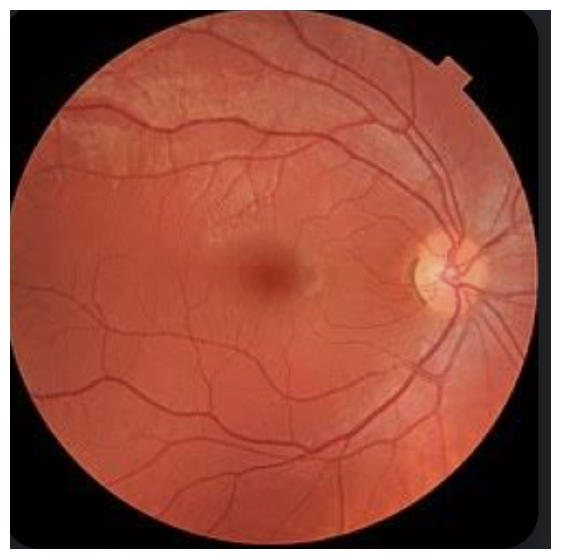

In [21]:
import os
from PIL import Image
import matplotlib.pyplot as plt

desktop = "/Users/aryanshinde/Desktop"

# Find the screenshot containing 9.23.55
matches = [
    os.path.join(desktop, f)
    for f in os.listdir(desktop)
    if "9.23.55" in f
]

print("Found:", matches)

test_path = matches[0]

img = Image.open(test_path)

plt.figure(figsize=(10, 7))
plt.imshow(img)
plt.axis("off")
plt.show()

Blur score: 26.21232528678003


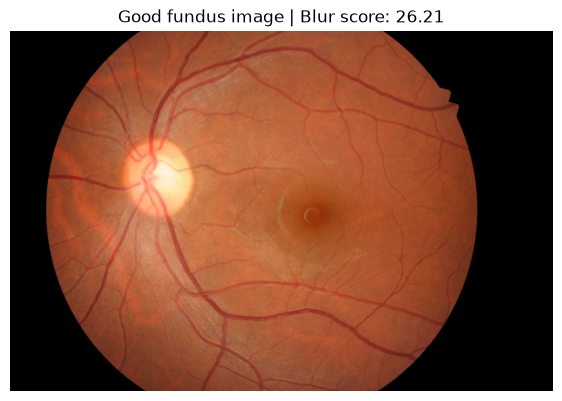

In [22]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

def calculate_blur_score(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Could not read image: {image_path}")

    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Higher variance = sharper image
    blur_score = cv2.Laplacian(gray, cv2.CV_64F).var()

    return blur_score


# Use an existing good IDRiD image
good_fundus = "/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon/IDRiD Dataset/Train/images/IDRiD_0001.jpg"

score = calculate_blur_score(good_fundus)

print("Blur score:", score)

img = Image.open(good_fundus)

plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title(f"Good fundus image | Blur score: {score:.2f}")
plt.show()

Original (good) score : 26.21232528678003
Blurred score         : 1.047928206853006


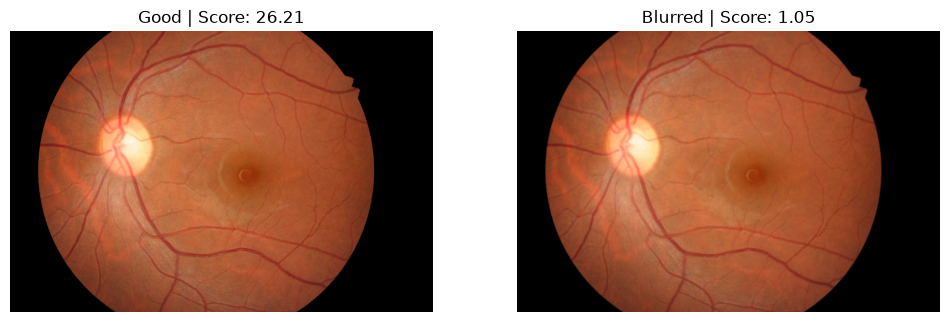

In [23]:
# Create an artificially blurred version of the same fundus image

image = cv2.imread(good_fundus)

blurred = cv2.GaussianBlur(image, (21, 21), 0)

blurred_path = "blurred_test_fundus.jpg"
cv2.imwrite(blurred_path, blurred)

# Calculate both scores
original_score = calculate_blur_score(good_fundus)
blurred_score = calculate_blur_score(blurred_path)

print("Original (good) score :", original_score)
print("Blurred score         :", blurred_score)

# Display both
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axes[0].set_title(f"Good | Score: {original_score:.2f}")
axes[0].axis("off")

axes[1].imshow(cv2.cvtColor(blurred, cv2.COLOR_BGR2RGB))
axes[1].set_title(f"Blurred | Score: {blurred_score:.2f}")
axes[1].axis("off")

plt.show()

In [24]:
import os

fundus_dir = "/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon/IDRiD Dataset/Train/images"

image_files = [
    os.path.join(fundus_dir, f)
    for f in os.listdir(fundus_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
][:20]

scores = []

for path in image_files:
    score = calculate_blur_score(path)
    scores.append(score)

print("Number of images tested:", len(scores))
print("Minimum score:", min(scores))
print("Maximum score:", max(scores))
print("Average score:", sum(scores) / len(scores))
print("Scores:")
for path, score in zip(image_files, scores):
    print(f"{os.path.basename(path)} -> {score:.2f}")

Number of images tested: 20
Minimum score: 11.020634216536068
Maximum score: 27.984621795557977
Average score: 18.327055903323018
Scores:
IDRiD_0212.jpg -> 13.65
IDRiD_0574.jpg -> 11.02
IDRiD_0560.jpg -> 24.92
IDRiD_1118.jpg -> 14.45
IDRiD_0206.jpg -> 21.99
IDRiD_1130.jpg -> 14.84
IDRiD_0548.jpg -> 26.38
IDRiD_1124.jpg -> 19.26
IDRiD_0979.jpg -> 14.32
IDRiD_0789.jpg -> 18.22
IDRiD_0951.jpg -> 15.55
IDRiD_0945.jpg -> 27.98
IDRiD_0776.jpg -> 20.27
IDRiD_0010.jpg -> 17.09
IDRiD_0004.jpg -> 17.85
IDRiD_0762.jpg -> 17.34
IDRiD_0992.jpg -> 18.81
IDRiD_0038.jpg -> 17.67
IDRiD_0986.jpg -> 17.64
IDRiD_0819.jpg -> 17.30


In [25]:
import os
import numpy as np

fundus_dir = "/Users/aryanshinde/Projects/Eye Retiroscopy Hackathon/IDRiD Dataset/Train/images"

all_fundus_files = [
    os.path.join(fundus_dir, f)
    for f in os.listdir(fundus_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

all_scores = np.array([
    calculate_blur_score(path)
    for path in all_fundus_files
])

print("Images tested:", len(all_scores))
print("Minimum:", all_scores.min())
print("5th percentile:", np.percentile(all_scores, 5))
print("10th percentile:", np.percentile(all_scores, 10))
print("Median:", np.median(all_scores))
print("Average:", all_scores.mean())
print("Maximum:", all_scores.max())

Images tested: 1239
Minimum: 2.8388974964129585
5th percentile: 8.096878047828575
10th percentile: 11.012849135332917
Median: 17.910495814620813
Average: 18.149515142221485
Maximum: 33.65856980423289


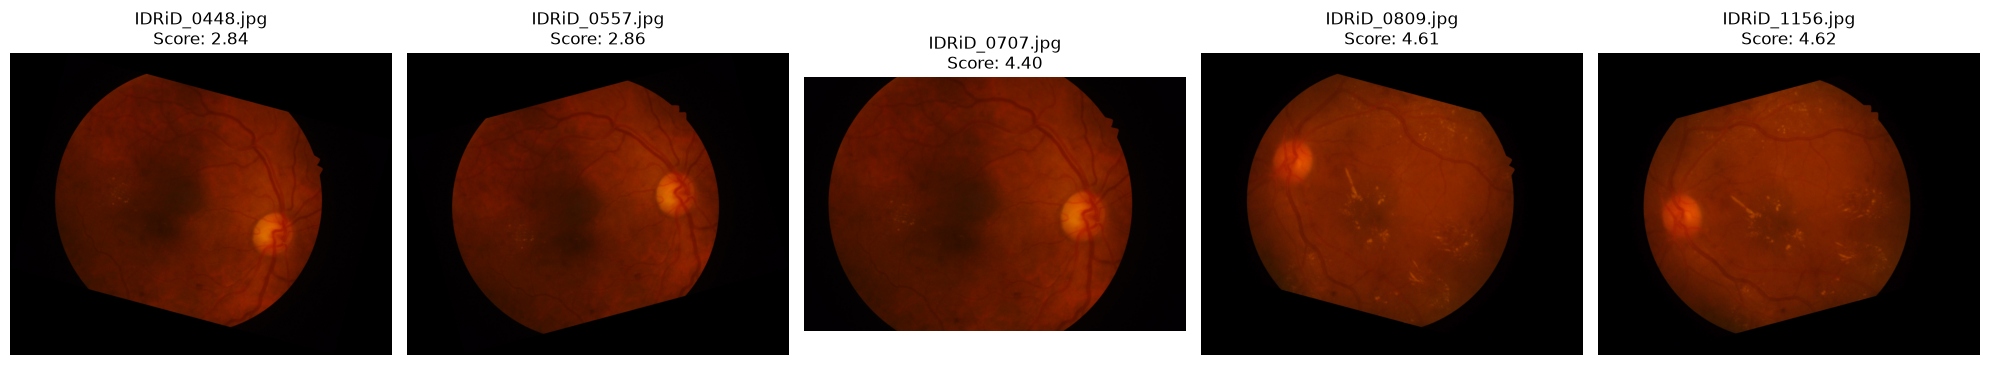

In [26]:
# Show the 5 lowest-scoring IDRiD images

sorted_pairs = sorted(
    zip(all_fundus_files, all_scores),
    key=lambda x: x[1]
)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for ax, (path, score) in zip(axes, sorted_pairs[:5]):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img)
    ax.set_title(f"{os.path.basename(path)}\nScore: {score:.2f}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [27]:
def calculate_fundus_blur_score(image_path):
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(image_path)

    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

    # Find the retinal field (ignore mostly-black background)
    mask = gray > 10

    if not np.any(mask):
        return 0.0

    # Bounding box around retinal region
    ys, xs = np.where(mask)

    x1, x2 = xs.min(), xs.max()
    y1, y2 = ys.min(), ys.max()

    retinal = gray[y1:y2+1, x1:x2+1]

    # Resize to a consistent size
    retinal = cv2.resize(retinal, (512, 512))

    # Sharpness score
    score = cv2.Laplacian(
        retinal,
        cv2.CV_64F
    ).var()

    return float(score)


# Compare the same good and blurred images
good_score = calculate_fundus_blur_score(good_fundus)
blurred_score = calculate_fundus_blur_score(blurred_path)

print("Good fundus score    :", good_score)
print("Blurred fundus score :", blurred_score)

Good fundus score    : 225.6950184069574
Blurred fundus score : 29.14548617688706


In [28]:
# Measure the improved blur score across all IDRiD fundus images

all_fundus_scores = np.array([
    calculate_fundus_blur_score(path)
    for path in all_fundus_files
])

print("Images tested:", len(all_fundus_scores))
print("Minimum:", all_fundus_scores.min())
print("5th percentile:", np.percentile(all_fundus_scores, 5))
print("10th percentile:", np.percentile(all_fundus_scores, 10))
print("Median:", np.median(all_fundus_scores))
print("Average:", all_fundus_scores.mean())
print("Maximum:", all_fundus_scores.max())

Images tested: 1239
Minimum: 38.58580884244293
5th percentile: 97.32178153687856
10th percentile: 124.46278930210975
Median: 193.63302594330162
Average: 196.8311355616973
Maximum: 415.04499449953437


In [29]:
# Test different levels of artificial blur

image = cv2.imread(good_fundus)

blur_tests = {
    "Original": image,
    "Mild blur": cv2.GaussianBlur(image, (9, 9), 0),
    "Medium blur": cv2.GaussianBlur(image, (15, 15), 0),
    "Strong blur": cv2.GaussianBlur(image, (21, 21), 0),
    "Very strong blur": cv2.GaussianBlur(image, (31, 31), 0),
}

for name, test_image in blur_tests.items():
    temp_path = f"temp_{name.replace(' ', '_').lower()}.jpg"
    cv2.imwrite(temp_path, test_image)

    score = calculate_fundus_blur_score(temp_path)

    print(f"{name:18} → {score:.2f}")

Original           → 226.20
Mild blur          → 83.85
Medium blur        → 47.80
Strong blur        → 29.15
Very strong blur   → 14.77


In [30]:
thresholds = [50, 60, 70, 80, 90, 100]

print("Valid IDRiD images that would be rejected:\n")

for threshold in thresholds:
    rejected = np.sum(all_fundus_scores < threshold)
    percentage = rejected / len(all_fundus_scores) * 100

    print(
        f"Threshold {threshold:>3}: "
        f"{rejected:>3} / {len(all_fundus_scores)} "
        f"({percentage:.2f}%)"
    )

Valid IDRiD images that would be rejected:

Threshold  50:   3 / 1239 (0.24%)
Threshold  60:   4 / 1239 (0.32%)
Threshold  70:  18 / 1239 (1.45%)
Threshold  80:  29 / 1239 (2.34%)
Threshold  90:  48 / 1239 (3.87%)
Threshold 100:  66 / 1239 (5.33%)


In [31]:
import shutil
import os

# Copy the blurred test image into the backend uploads folder
source = "blurred_test_fundus.jpg"
destination = "/Users/aryanshinde/Music/OcuSense/backend/uploads/blurred_test_fundus.jpg"

shutil.copy2(source, destination)

print("Copied to:", destination)
print("Exists:", os.path.exists(destination))


Copied to: /Users/aryanshinde/Music/OcuSense/backend/uploads/blurred_test_fundus.jpg
Exists: True
